# _4.4.3. (Fine-Grained) classification using NN_


Main topics of the current notebook is to focus on applying NN to the problem of anomaly detection, i.e., identifying anomaly severity levels ranging from 5% to 50%, along with encompassing categories : reorder, duplicate, corrupt anpmalies or a normal case. 


#### _a. Load Data_

Recall, the dataset was already cleaned and normalized _(using StandardScaler)_. Columns with zero or near-zero variance deleted.

In [1]:
from xgboost import XGBClassifier

import seaborn as sns 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import os
import torch
import time 

from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV, train_test_split

from scipy.stats import uniform, randint

from skopt import BayesSearchCV

%matplotlib inline

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

In [3]:
scaled_new_dataset = "data/scaled_new_godash_dataset.csv"
scaled_new_df = pd.read_csv(scaled_new_dataset, index_col=0)

scaled_new_df.head(5)

,Seg_id,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,Act_Rate,Byte_Size,Buff_Level,Width,...,Yu,algo,nb_nodes,mos,MOS,mos_label,anomaly,level,tag2,tag
0,-1.697807,-0.445033,-0.204334,-0.164204,-1.294465,-1.160341,-1.160370,-1.160361,-0.833377,-1.247338,...,0.360347,-1.462647,0.524565,-1.043858,-0.045817,bad,0,-1.083746,False,0
1,-1.640070,-0.441006,-0.198458,-0.164204,-1.294465,-0.396335,-1.008632,-1.008502,-0.575036,-1.247338,...,0.360347,-1.462647,0.524565,-1.114816,-0.045817,bad,0,-1.083746,False,0
2,-1.582333,-0.436192,-0.186196,-0.164204,-1.108483,0.193475,-0.664977,-0.665158,-0.460461,-0.978685,...,0.367256,-1.462647,0.524565,-0.964049,-0.045817,bad,0,-1.083746,False,0
3,-1.524596,-0.430804,-0.169590,-0.164204,-0.826439,0.384235,-0.245217,-0.244990,-0.363067,-0.799582,...,0.378520,-1.462647,0.524565,-0.956997,-0.045817,bad,0,-1.083746,False,0
4,-1.466860,-0.425614,-0.169846,-0.164204,-0.422082,0.397624,-0.242853,-0.242699,-0.259859,-0.665255,...,0.394329,-1.462647,0.524565,-0.943719,-0.045817,bad,0,-1.083746,False,0


In [5]:
# Recall, all the following have been deleted --> ['Seg_Dur', 'Codec', 'FPS', 'Protocol']
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level', 'Width',
                'Height', 'Play_Pos', 'RTT', 'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag']

new_df = scaled_new_df [all_features]
selected_features = all_features[:-4]
target = "tag"

In [6]:
dataset_name = 'new_godash_dataset'
train = new_df.copy()
n_total = len(train)
print ("n_total = ", n_total)
print ("nb features =", len(train.columns))
print ("nan values =", train.isna().sum().sum())

n_total =  85596
nb features = 27
nan values = 0


#### _b. Label Encode target y_

The basic Idea here is to see the problem as a multi-class classification problem. 

The population is already devided into different anomalies tag using "tag" column.

In [7]:
# 'normal':0, 
# 'reorder5':1, 'reorder10':2, 'reorder20':3, 'reorder30':4, 'reorder40':5, 'reorder50':6,
# 'duplicate5':7, 'duplicate10':8, 'duplicate20':9, 'duplicate30':10, 'duplicate40':11, 'duplicate50':12,        
# 'corrupt5':13,   'corrupt10':14,   'corrupt20':15, 'corrupt30':16,  'corrupt40':17,  'corrupt50':18
train[target].value_counts(normalize=True)

0     0.253049
15    0.042058
3     0.042058
14    0.042058
1     0.042058
2     0.042058
7     0.042058
6     0.042058
13    0.042058
8     0.042058
9     0.042058
4     0.042058
16    0.042058
12    0.042058
5     0.042058
10    0.042058
11    0.042058
17    0.041182
18    0.032840
Name: tag, dtype: float64

#### _c. Split_

In [8]:
train_val_indices, test_indices = train_test_split(range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices =    train_test_split(train_val_indices, test_size=0.2 / 0.6, random_state=0)

# This is a generic pipeline but actually no categorical features are available for this dataset
unused_feat = ["mos_label", 'tag', 'level', 'anomaly']
features = [ col for col in selected_features if col not in unused_feat+[target]] 

print ("len(features) =", len(features))

if os.getenv("CI", False):
# Take only a subsample to run CI
    X_train = train[features].values[train_indices][:1000,:]
    y_train = train[target].values[train_indices][:1000]
else:
    X_train = train[features].values[train_indices]
    y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("shape(X_train) :", X_train.shape)
print ("shape(y_train) :", y_train.shape)

len(features) = 22
shape(X_train) : (45650, 22)
shape(y_train) : (45650,)


#### _d. Check CUDA support_

In [9]:
print ("Is CUDA available :", torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print ("Device :", DEVICE)

Is CUDA available : True
Device : cuda


### _e. Classification using NN_

A neural network is a computational model inspired by the structure and functioning of the human brain. A Neural network is _**trained**_ using data, adjusting the weights based on the difference between predicted and actual outcomes. This process, known as _**backpropagation**_, enables the network to _**learn complex patterns**_ and _**relationships**_ within the data.

In our case, a neural network is trained to categorize instances into four classes, each representing an anomaly or normal behavior. 


<br>

<div style="float: center;"><img  src="docs\pics\multiclass_nn.png"  alt="multi-class"  width="450"/>
</div>

</br>

We use **_TensorFlow_**, the free and open-source library, used across a range of tasks but particularly focusing on training and inference of deep neural networks _[[wikipedia]](https://en.wikipedia.org/wiki/TensorFlow)_

In [15]:
# os.environ["CUDA_VISIBLE_DEVICES"]=""
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

In [16]:
print(tf.__version__)

print('1: ', tf.config.list_physical_devices('GPU'))
print('2: ', tf.test.is_built_with_cuda)
print('3: ', tf.test.gpu_device_name())
print('4: ', tf.config.get_visible_devices())

2.3.0
1:  []
2:  <function is_built_with_cuda at 0x000001D058C2A8B8>
3:  
4:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [12]:
# Again, Check if TensorFlow is using GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


_**a. Case without dropout layers**_

Here in we will try a simple architecture with no _**dropout**_ layer and lighter _**(32x16)**_ architecture. 

In [13]:
start_time = time.time()

# Define your model
model = models.Sequential()

# Add the input layer and the first hidden layer
model.add(layers.Dense(16, activation='relu', input_shape=(22,)))
# Add more hidden layers if needed
model.add(layers.Dense(8, activation='relu'))

# Output layer with softmax activation for multiclass classification
model.add(layers.Dense(19, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use categorical_crossentropy if your labels are one-hot encoded
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 16)                368       
_________________________________________________________________
dense_1 (Dense)              (None, 8)                 136       
_________________________________________________________________
dense_2 (Dense)              (None, 19)                171       
Total params: 675
Trainable params: 675
Non-trainable params: 0
_________________________________________________________________


In [14]:
# Train the model and store the history
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_valid, y_valid))

print(f"Training completed in +{(time.time()-start_time)//60:.2f} min.")

Epoch 1/100
1427/1427 [==============================] - 4s 3ms/step - loss: 2.1095 - accuracy: 0.3415 - val_loss: 1.7926 - val_accuracy: 0.3913
Epoch 2/100
1427/1427 [==============================] - 4s 3ms/step - loss: 1.6815 - accuracy: 0.4159 - val_loss: 1.5889 - val_accuracy: 0.4377
Epoch 3/100
1427/1427 [==============================] - 4s 3ms/step - loss: 1.5511 - accuracy: 0.4501 - val_loss: 1.5028 - val_accuracy: 0.4614
Epoch 4/100
1427/1427 [==============================] - 4s 2ms/step - loss: 1.4758 - accuracy: 0.4690 - val_loss: 1.4404 - val_accuracy: 0.4805
Epoch 5/100
1427/1427 [==============================] - 5s 3ms/step - loss: 1.4249 - accuracy: 0.4846 - val_loss: 1.3916 - val_accuracy: 0.4954
Epoch 6/100
1427/1427 [==============================] - 4s 3ms/step - loss: 1.3866 - accuracy: 0.4956 - val_loss: 1.3603 - val_accuracy: 0.5087
Epoch 7/100
1427/1427 [==============================] - 4s 3ms/step - loss: 1.3550 - accuracy: 0.5069 - val_loss: 1.3372 - val_ac

In [17]:
results = model.evaluate(X_test, y_test)
dict(zip(model.metrics_names, results))

535/535 [==============================] - 1s 3ms/step - loss: 1.1166 - accuracy: 0.5913


{'loss': 1.1165634393692017, 'accuracy': 0.5912967324256897}

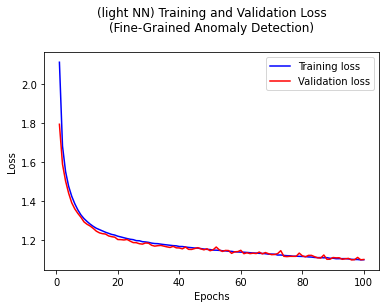

In [18]:
# Extract training and validation loss from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the training and validation loss
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, c="blue", label='Training loss')
plt.plot(epochs, val_loss, c="red", label='Validation loss')
plt.title('(light NN) Training and Validation Loss\n(Fine-Grained Anomaly Detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [19]:
# y_pred has shape (9473, 4)
y_vect_pred = model.predict(X_test)

y_pred = np.argmax(y_vect_pred, axis=1)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)


# Display a classification report
print("\n(light NN) Classification Report (Fine-Grained Anomaly Detection)\n")
print(classification_report(y_test, y_pred))


(light NN) Classification Report (Fine-Grained Anomaly Detection)

              precision    recall  f1-score   support

           0       0.80      0.96      0.87      4319
           1       0.34      0.14      0.19       706
           2       0.68      0.15      0.25       684
           3       0.51      0.54      0.52       772
           4       0.50      0.31      0.39       706
           5       0.40      0.54      0.46       698
           6       0.42      0.55      0.48       687
           7       0.40      0.28      0.33       750
           8       0.53      0.58      0.55       708
           9       0.32      0.27      0.29       732
          10       0.35      0.06      0.11       762
          11       0.33      0.65      0.44       712
          12       0.43      0.37      0.40       734
          13       0.26      0.32      0.29       716
          14       0.54      0.57      0.55       743
          15       0.76      0.76      0.76       727
          16 

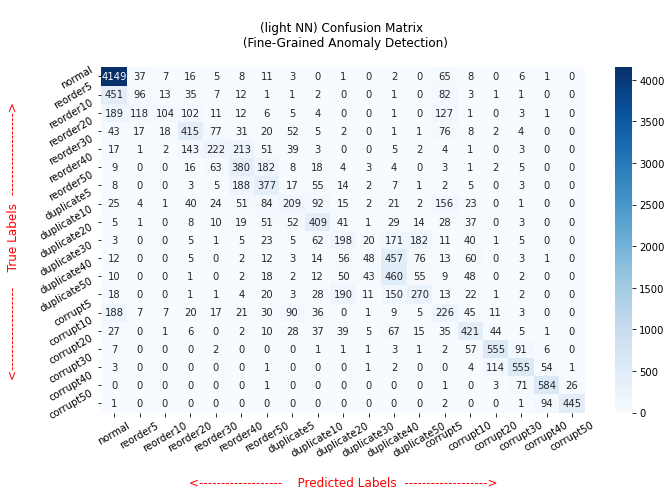

In [21]:
labaled_classes = [ 'normal', 
                    'reorder5', 'reorder10', 'reorder20', 
                    'reorder30', 'reorder40', 'reorder50',
                   'duplicate5', 'duplicate10', 'duplicate20', 
                    'duplicate30', 'duplicate40', 'duplicate50',        
                    'corrupt5',   'corrupt10',   'corrupt20', 
                    'corrupt30',  'corrupt40',  'corrupt50']

classes = np.unique(y_train) 

classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)

plt.title("\n(light NN) Confusion Matrix \n (Fine-Grained Anomaly Detection)\n")
plt.tight_layout()
plt.show()

_**b. Case of more complex Architecture**_

Next, we will try more complex architecture with two dropout layers, l2 regularization and a more complex _**(64x32)**_ architecture. 

In [22]:
start_time = time.time()

# Define your model
complex_model = models.Sequential()

# Add the input layer and the first hidden layer
complex_model.add(layers.Dense(64, activation='relu', input_shape=(22,), kernel_regularizer=regularizers.l2(0.01)))
complex_model.add(layers.Dropout(0.5))
# Add more hidden layers if needed
complex_model.add(layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
complex_model.add(layers.Dropout(0.5))

# Output layer with softmax activation for multiclass classification
complex_model.add(layers.Dense(19, activation='softmax'))

# Compile the model
complex_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use categorical_crossentropy if your labels are one-hot encoded
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

complex_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_3 (Dense)              (None, 64)                1472      
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_4 (Dense)              (None, 32)                2080      
_________________________________________________________________
dropout_1 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_5 (Dense)              (None, 19)                627       
Total params: 4,179
Trainable params: 4,179
Non-trainable params: 0
_________________________________________________________________


In [23]:
# Train the model and store the history
history = complex_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_valid, y_valid))

print(f"Training completed in +{(time.time()-start_time)//60:.2f} min.")

Epoch 1/100
1427/1427 [==============================] - 6s 4ms/step - loss: 2.5922 - accuracy: 0.2927 - val_loss: 2.0950 - val_accuracy: 0.3741
Epoch 2/100
1427/1427 [==============================] - 6s 4ms/step - loss: 2.1212 - accuracy: 0.3507 - val_loss: 1.9404 - val_accuracy: 0.3985
Epoch 3/100
1427/1427 [==============================] - 7s 5ms/step - loss: 2.0335 - accuracy: 0.3696 - val_loss: 1.8700 - val_accuracy: 0.4119
Epoch 4/100
1427/1427 [==============================] - 6s 4ms/step - loss: 1.9923 - accuracy: 0.3825 - val_loss: 1.8330 - val_accuracy: 0.4214
Epoch 5/100
1427/1427 [==============================] - 6s 4ms/step - loss: 1.9659 - accuracy: 0.3868 - val_loss: 1.8098 - val_accuracy: 0.4301
Epoch 6/100
1427/1427 [==============================] - 6s 4ms/step - loss: 1.9485 - accuracy: 0.3902 - val_loss: 1.7975 - val_accuracy: 0.4296
Epoch 7/100
1427/1427 [==============================] - 6s 4ms/step - loss: 1.9323 - accuracy: 0.3890 - val_loss: 1.7823 - val_ac

In [24]:
results = complex_model.evaluate(X_test, y_test)
dict(zip(complex_model.metrics_names, results))

535/535 [==============================] - 1s 3ms/step - loss: 1.5728 - accuracy: 0.4823


{'loss': 1.5728477239608765, 'accuracy': 0.48230141401290894}

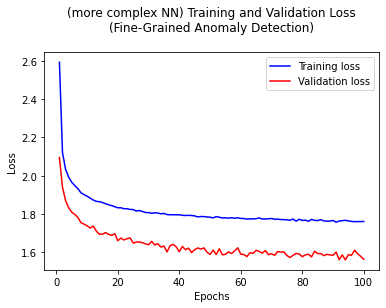

In [25]:
# Extract training and validation loss from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the training and validation loss
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, c="blue", label='Training loss')
plt.plot(epochs, val_loss, c="red", label='Validation loss')
plt.title('(more complex NN) Training and Validation Loss\n(Fine-Grained Anomaly Detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [26]:
# y_pred has shape (9473, 4)
y_vect_pred = complex_model.predict(X_test)

y_pred = np.argmax(y_vect_pred, axis=1)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Display a classification report
print("\n(more complex NN) Classification Report (Fine-Grained Anomaly Detection)\n")
print(classification_report(y_test, y_pred))


(more complex NN) Classification Report (Fine-Grained Anomaly Detection)

              precision    recall  f1-score   support

           0       0.56      1.00      0.72      4319
           1       0.00      0.00      0.00       706
           2       0.00      0.00      0.00       684
           3       0.38      0.03      0.06       772
           4       0.35      0.34      0.34       706
           5       0.15      0.02      0.04       698
           6       0.31      0.65      0.42       687
           7       0.37      0.12      0.18       750
           8       0.47      0.50      0.48       708
           9       0.31      0.11      0.17       732
          10       0.08      0.00      0.01       762
          11       0.25      0.73      0.37       712
          12       0.23      0.17      0.19       734
          13       0.40      0.11      0.17       716
          14       0.71      0.32      0.45       743
          15       0.78      0.64      0.70       727
      

C:\Users\kabou\.conda\envs\py37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\kabou\.conda\envs\py37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\kabou\.conda\envs\py37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


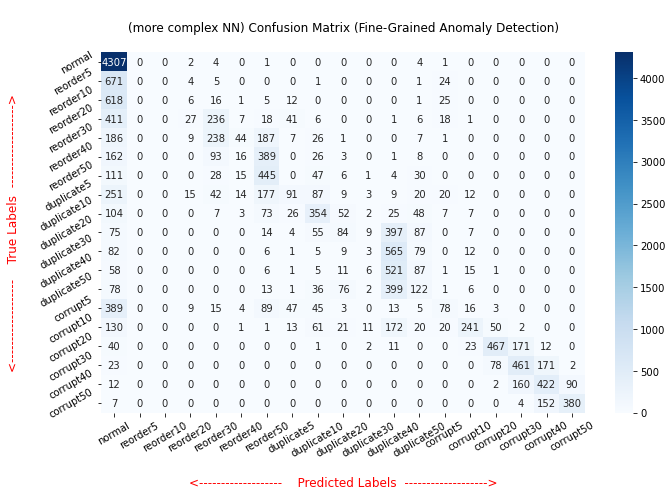

In [27]:
labaled_classes = [ 'normal', 
                    'reorder5', 'reorder10', 'reorder20', 
                    'reorder30', 'reorder40', 'reorder50',
                   'duplicate5', 'duplicate10', 'duplicate20', 
                    'duplicate30', 'duplicate40', 'duplicate50',        
                    'corrupt5',   'corrupt10',   'corrupt20', 
                    'corrupt30',  'corrupt40',  'corrupt50']

classes = np.unique(y_train) 

classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)
plt.title("\n(more complex NN) Confusion Matrix (Fine-Grained Anomaly Detection)\n")
plt.tight_layout()
plt.show()

_**c. Discussion**_

The problem of multi-class classification, and as we saw in the exploratory data analysis step, is not so complex. This explain the ability of sampler architecture to obtain mush better performance compared to the more complex one. 

Thus, we will pick the sampler variante as a representatif of neural network in our use case.